# Accessing an Open Datasets

The Open AI, or Open Data is considered to be key KPI for the safe and sound AI.

Reason: The AI model generate the output based on inputs, So we needed to know the input. Only and one of effective to get to know input is the Open Data:

Open Data: The data which is accesible to everybody

# Online Retail Data, Lets work with it.
https://archive.ics.uci.edu/dataset/352/online+retail

In [2]:
import pandas as pd

df = pd.read_csv("Online Retail.csv", encoding='latin1')


Dataset downloaded and extracted successfully.


FileNotFoundError: [Errno 2] No such file or directory: 'Online Retail.csv'

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


# Basic KPIs of Data

In [ ]:
'''0.A. Columns of the data'''
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
'''0. B Shape of the Data '''
df.shape

(541909, 8)

In [ ]:
'''0.C describe'''
df.describe()

'''Always report

1. Minimum Value
2. Maximum Value
3. Mean
4. Std. Deviation

'''

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# What are key test for normality

--> Kolmogrow-Shmirnow test
--> Shipro-Wilk test


'''HOW TO make'''
=> Log transformation ==> Making data linear
=> Box-Cox transformation
=> Z-Score transformation => Standerization of values.  


# 1. Data Completeness

In [ ]:
'''1.1. Missing Values'''
import pandas as pd

missing_values_count = df.isnull().sum()

print("Missing values per column:")
print(missing_values_count)

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
'''1.2 Pecetange of the Missing Values'''

total_rows = len(df)

missing_info = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / total_rows) * 100
})

print(missing_info)


             missing_count  missing_percentage
InvoiceNo                0            0.000000
StockCode                0            0.000000
Description           1454            0.268311
Quantity                 0            0.000000
InvoiceDate              0            0.000000
UnitPrice                0            0.000000
CustomerID          135080           24.926694
Country                  0            0.000000


# Conclusion
'''
Our Data is mostly Okay. But there is are issues with Customer-ID

Report: We will needed to report Missing Values.

'''

In [ ]:
''''What is Soultion to handle the missing values of the Data ''''

'''

1. Date
2. product Catagory

'''



In [ ]:
df_missiong = df[df['CustomerID'].isna()]

In [ ]:
df_missiong

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [ ]:
df_missiong["InvoiceDate"] = pd.to_datetime(df_missiong["InvoiceDate"] )

C:\Users\AL-MALAK\AppData\Local\Temp\ipykernel_8528\457920370.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missiong["InvoiceDate"] = pd.to_datetime(df_missiong["InvoiceDate"] )


<Axes: xlabel='InvoiceDate', ylabel='Count'>

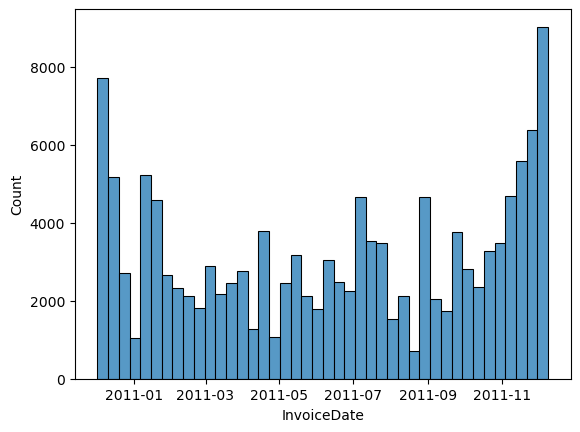

In [ ]:
import seaborn as sns

sns.histplot(df_missiong["InvoiceDate"])

# 2. Data Latency

In [ ]:
'''2.1 minimum and Maxmimum Date'''
# Make sure InvoiceDate is in datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()

print(f"Minimum Invoice Date: {min_date}")
print(f"Maximum Invoice Date: {max_date}")


Minimum Invoice Date: 2010-12-01 08:26:00
Maximum Invoice Date: 2011-12-09 12:50:00


In [ ]:
'''Data Age'''

from datetime import datetime

data_age = datetime.now() - df['InvoiceDate'].max()
print(f"Data is {data_age} old ")


Data is 4921 days 01:01:00.293101 old 


In [ ]:
# Make sure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract year and month as a new column (e.g., "2010-12")
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Count number of records per month
monthly_counts = df.groupby('YearMonth').size().reset_index(name='Count')

print(monthly_counts)


   YearMonth  Count
0    2010-12  42481
1    2011-01  35147
2    2011-02  27707
3    2011-03  36748
4    2011-04  29916
5    2011-05  37030
6    2011-06  36874
7    2011-07  39518
8    2011-08  35284
9    2011-09  50226
10   2011-10  60742
11   2011-11  84711
12   2011-12  25525


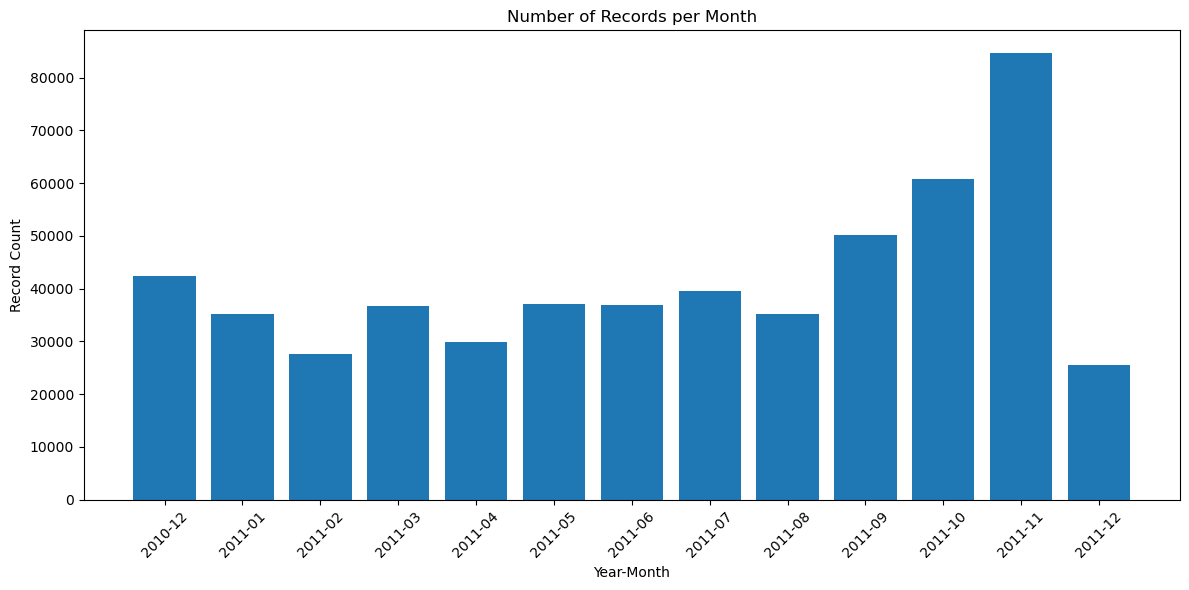

In [ ]:
import matplotlib.pyplot as plt

monthly_counts['YearMonth'] = monthly_counts['YearMonth'].astype(str)

plt.figure(figsize=(12,6))
plt.bar(monthly_counts['YearMonth'], monthly_counts['Count'])
plt.xticks(rotation=45)
plt.title('Number of Records per Month')
plt.xlabel('Year-Month')
plt.ylabel('Record Count')
plt.tight_layout()
plt.show()


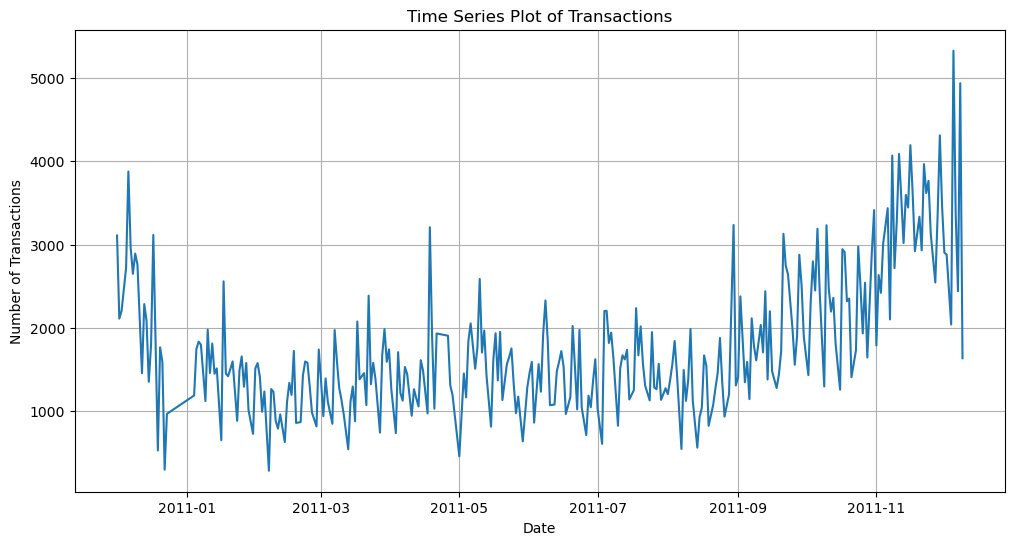

In [ ]:
# Group data by date and count the number of entries
time_series_data = df.groupby(df['InvoiceDate'].dt.date).size()


# Plot the time series data
plt.figure(figsize=(12, 6))
time_series_data.plot(kind='line')
plt.title('Time Series Plot of Transactions')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid()
plt.show()

# 3. Data Consistency

In [ ]:
'''3.1. Data Info'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   YearMonth    541909 non-null  period[M]     
dtypes: datetime64[ns](1), float64(2), int64(1), object(4), period[M](1)
memory usage: 37.2+ MB


In [ ]:
print(df.dtypes)
# or
print(df.apply(lambda x: x.map(type).nunique()))


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
YearMonth           period[M]
dtype: object
InvoiceNo      1
StockCode      1
Description    2
Quantity       1
InvoiceDate    1
UnitPrice      1
CustomerID     1
Country        1
YearMonth      1
dtype: int64


# 4. Error Rate



In [ ]:
# 1. It i same which we have calculated earlier

missing_rate = df.isnull().mean() * 100
print(missing_rate)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
YearMonth       0.000000
dtype: float64


In [ ]:
# 2. Duplicates rate

duplicate_rate = df.duplicated().mean() * 100
print(duplicate_rate)

0.9721189350979592


In [ ]:
# #. Outlier Rate:

Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df['UnitPrice'] < Q1 - 1.5 * IQR) | (df['UnitPrice'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

7.312482354048373


In [ ]:
'''Can we check the outliers in any-other varaible?'''

# 5. Data Accuracy

# 5.1. For An Individual varaibles:=> With price

In [ ]:
minimum_price = df['UnitPrice'].min()
max_price = df['UnitPrice'].max()

print("The minimum recorded price is", minimum_price)

print("The maximum recorded price is", max_price)

The minimum recorded price is -11062.06
The maximum recorded price is 38970.0


In [ ]:
'''How can Our Price be negative'''
negative_price_count = (df['UnitPrice'] < 0).sum()
print("Number of records with negative UnitPrice:", negative_price_count)


Number of records with negative UnitPrice: 2


In [ ]:
df = df[df['UnitPrice'] >= 0]


# The Overall Data Accuracy KPIs

In [ ]:
valid_quantity = df['Quantity'] > 0
valid_price = df['UnitPrice'] > 0
valid_customer = df['CustomerID'].notnull()

accurate_records = df[valid_quantity & valid_price & valid_customer]
data_accuracy_rate = (len(accurate_records) / len(df)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")


✅ Data Accuracy Rate: 73.42%


In [ ]:
invalid_records = df[~(valid_quantity & valid_price & valid_customer)]
invalid_value_rate = (len(invalid_records) / len(df)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")


❌ Invalid Value Rate: 26.58%


In [ ]:
valid_countries = ["United Kingdom", "France", "Germany", "EIRE", "Spain", "Netherlands"]
matched_country = df['Country'].isin(valid_countries)
ref_match_rate = (matched_country.sum() / len(df)) * 100
print(f"🌍 Reference Data Match Rate (Country): {ref_match_rate:.2f}%")


🌍 Reference Data Match Rate (Country): 97.18%


In [ ]:
duplicate_rows = df.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(df)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")


📄 Duplicate Accuracy Rate: 99.03%


In [ ]:
unit_price_accuracy = (df['UnitPrice'] > 0).sum() / len(df) * 100
print(f"💰 Unit Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")


💰 Unit Price Field Accuracy Rate: 99.54%
